# Hadron distributions: background, background + wake, jet

A first look at the hadron files of a campaign: the $\eta$, $\varphi$ and $p_T$ distributions of

| label | file | what |
|---|---|---|
| **bkg** | `<stem>_hadrons_bulk_bg.h5` | iSS on the background leg's surface (MUSIC_1, no jet) |
| **bkg + wake** | `<stem>_hadrons_bulk_jet.h5` | iSS on the jet leg's surface (MUSIC_2, with the liquefier source) |
| **jet** | `<stem>_hadrons_jet_frag.h5` | ColorlessHadronization of the surviving final partons |

and the **wake** itself, $\langle\text{bkg + wake}\rangle - \langle\text{bkg}\rangle$, each event against
the background it was run on.

**Input.** `HADRON_DIR` is a directory of `hadronize.py` output: every `<stem>_particlize.h5` in it
is one production file, read together with its three hadron files as one data set
(`jetscape.hadrons_h5.HadronFileReader`). The particlize file is required, because it maps each
event to its background (`--reuse`) and pins the hadron files to the run (`file_uuid`).
`MAX_EVENTS` caps the number of events (the first ones, in file order). Both can also be set from the
environment:

    HADRON_DIR=/path/to/out MAX_EVENTS=200 jupyter nbconvert --to notebook --execute hadron_distributions.ipynb

**Normalisation.** Every curve is per event: each event's oversamples (or fragmentations) are
averaged first, then the events are averaged, so every event weighs the same whatever its
`--oversample`. The error bands are the **hadron sampling noise** of these averages
(compound-Poisson). They do *not* include event-to-event fluctuations of the collisions, which
dominate once there are many events.

In [1]:
%matplotlib inline
import os
import sys
import time
try:  # registers Blosc, the default compression of the hadron files
    import hdf5plugin  # noqa: F401
except ImportError:
    print("note: pip install hdf5plugin -- needed for Blosc-compressed files (lzf files read without it)")
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join("..", "..", "python"))
from jetscape.hadrons_h5 import HadronFileReader, TAGS

# --- inputs ---------------------------------------------------------------------------------
HADRON_DIR = os.environ.get("HADRON_DIR", os.path.join("..", "prod_AuAu_0_10_jet", "out"))
MAX_EVENTS = int(os.environ.get("MAX_EVENTS", "0")) or None     # None: every event
SPECIES = "charged"        # 'charged', 'all' or a key of jetscape.hadrons_h5.SPECIES ('pi+', 'p', ...)
ETA_WINDOW = 1.0           # |eta| < ETA_WINDOW for the phi and pT distributions
PT_RANGE = (0.0, np.inf)   # GeV, for the eta and phi distributions

# --- binning: one 3-d histogram (eta, phi, pT) per file tag, projected with the cuts afterwards,
# so each hadron file is read once.  Cuts act on whole bins: put them on bin edges.
ETA_E = np.linspace(-8.0, 8.0, 65)
PHI_E = np.linspace(-np.pi, np.pi, 37)
PT_E = np.r_[np.arange(0.0, 3.0, 0.1), np.arange(3.0, 10.0, 0.5), np.arange(10.0, 30.0, 2.5),
             np.arange(30.0, 100.01, 10.0)]

# --- one fixed visual language: a hue AND a line style + marker per entity ------------------
STYLE = {
    "bulk_bg":  dict(color="#0072B2", ls="--", marker="s", label="bkg"),
    "bulk_jet": dict(color="#D55E00", ls="-",  marker="o", label="bkg + wake"),
    "jet_frag": dict(color="#009E73", ls="-.", marker="^", label="jet hadrons"),
    "wake":     dict(color="k",       ls="-",  marker="D", label="wake = (bkg + wake) $-$ bkg"),
}


def tidy(ax, xlabel=None, ylabel=None, title=None):
    """Recessive grid and spines, so the data is the most prominent thing in the frame."""
    ax.grid(True, alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title: ax.set_title(title, fontsize=10)
    return ax


plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
                     "legend.frameon": False})
print("ready")

ready


## 1. The data set

In [2]:
try:
    reader = HadronFileReader(HADRON_DIR)
except FileNotFoundError as exc:
    raise SystemExit(
        f"{exc}\n\nMake hadron files first, e.g. in ../prod_AuAu_0_10_jet (js_fno env):\n"
        "    python run_prod_jet.py --events 1 --seed 1 --write-particlize both\n"
        "    python hadronize.py out/AuAu_0_10_jet_seed0001_particlize.h5 --oversample 500 --n-frag 50\n"
        "or point HADRON_DIR at a campaign's output directory.")
missing = [t for t in TAGS if t not in reader.tags()]
if missing:
    raise SystemExit(f"not every production file in {HADRON_DIR} has {missing}: "
                     f"{[(s, reader.tags(i)) for i, s in enumerate(reader.stems)][:5]}")

events = reader.events(slice(0, MAX_EVENTS))
# the wake needs a surface on both legs (as HadronFileReader.jet_minus_background)
both = np.array([reader.n_samples("bulk_jet", e) > 0 and reader.n_samples("bulk_bg", e) > 0
                 for e in events], dtype=bool)
EVENTS = events[both]
N_EV = len(EVENTS)
if N_EV == 0:
    raise SystemExit("no event with a freeze-out surface on both legs")
N_SAMPLES = {t: np.array([reader.n_samples(t, e) for e in EVENTS]) for t in TAGS}

print(f"{HADRON_DIR}: {reader.n_files} production file(s), {reader.n_events} event(s)")
print(f"using {N_EV} event(s)" + (f" (MAX_EVENTS = {MAX_EVENTS})" if MAX_EVENTS else "")
      + (f"; {int((~both).sum())} skipped: an empty surface on one leg" if (~both).any() else ""))
for t in TAGS:
    n = N_SAMPLES[t]
    print(f"  {t:9s} samples per event: {n.min()}" + (f" .. {n.max()}" if n.max() != n.min() else "")
          + f"   precision {reader.precision(0)[t]}")
print(f"species: {SPECIES}")

../prod_AuAu_0_10_jet/out: 2 production file(s), 2 event(s)
using 2 event(s)
  bulk_jet  samples per event: 500   precision {'p': None, 'x': None}
  bulk_bg   samples per event: 500   precision {'p': None, 'x': None}
  jet_frag  samples per event: 50   precision {'p': None, 'x': None}
species: charged


## 2. Filling

One pass per file tag: a 3-d histogram in $(\eta, \varphi, p_T)$ of the selected species, per
event. The wake is the difference of the two bulk histograms; bkg and bkg + wake are independent
Cooper–Frye samplings of two fluids, so their errors add in quadrature. A background reused by
several events (`--reuse`) enters every one of them, and `HadronFileReader` counts its hadrons as
the correlated sum they are.

An event whose partons were all absorbed by the liquefier has no jet hadrons; the reader leaves such
events out of its average, so the jet histogram is rescaled to *per event of the whole selection*.

In [3]:
def lab_frame(ev, info):
    return ev.eta, ev.phi, ev.pt


def fill(values, edges):
    """{tag: (h, err)} per event of EVENTS, plus 'wake' = bulk_jet - bulk_bg."""
    out = {}
    for tag in TAGS:
        t0 = time.time()
        h, e = reader.hist(tag, values, edges, mask=SPECIES, events=EVENTS)
        scale = np.count_nonzero(N_SAMPLES[tag]) / N_EV      # reader: per event *with* samples
        out[tag] = (h * scale, e * scale)
        print(f"  {tag:9s} {h.sum() * scale:10.1f} hadrons per event inside the bins   "
              f"({time.time() - t0:.1f} s)")
    (hj, ej), (hb, eb) = out["bulk_jet"], out["bulk_bg"]
    out["wake"] = (hj - hb, np.hypot(ej, eb))
    return out


AXES = ("eta", "phi", "pt")
EDGES = {"eta": ETA_E, "phi": PHI_E, "pt": PT_E}
LAB = fill(lab_frame, [EDGES[a] for a in AXES])

  bulk_jet      5067.5 hadrons per event inside the bins   (1.5 s)
  bulk_bg       5050.2 hadrons per event inside the bins   (1.5 s)
  jet_frag        18.2 hadrons per event inside the bins   (0.0 s)


In [4]:
def project(hists, key, axis, cuts, axes=AXES, edges=EDGES):
    """d<N>/d(axis) per event of hists[key], summed over the other axes inside ``cuts``
    ({axis name: (lo, hi)}; a bin is kept when its centre is inside).  -> centres, y, err."""
    h, e = hists[key]
    keep = []
    for name in axes:
        c = 0.5 * (edges[name][:-1] + edges[name][1:])
        lo, hi = cuts.get(name, (-np.inf, np.inf)) if name != axis else (-np.inf, np.inf)
        keep.append((c >= lo) & (c < hi))
    ix = np.ix_(*keep)
    other = tuple(i for i, name in enumerate(axes) if name != axis)
    y = h[ix].sum(axis=other)
    err = np.sqrt((e[ix] ** 2).sum(axis=other))
    ed = edges[axis]
    w = np.diff(ed)
    return 0.5 * (ed[:-1] + ed[1:]), y / w, err / w


def draw(ax, x, y, err, key, log=False):
    """A line with markers every few bins, and its error band."""
    st = STYLE[key]
    lo, hi = y - err, y + err
    if log:     # nothing to show at or below zero; a band reaching zero is cut at y / 5
        good = y > 0
        y = np.where(good, y, np.nan)
        lo = np.where(good, np.maximum(lo, 0.2 * y), np.nan)
        hi = np.where(good, hi, np.nan)
    ax.fill_between(x, lo, hi, color=st["color"], alpha=0.22, lw=0)
    ax.plot(x, y, color=st["color"], ls=st["ls"], lw=1.6, marker=st["marker"], ms=4,
            markevery=max(1, len(x) // 12), label=st["label"])


def window_text(cuts, tex=True):
    parts = []
    if "eta" in cuts:
        parts.append(rf"$|\eta|<{cuts['eta'][1]:g}$" if tex else f"|eta| < {cuts['eta'][1]:g}")
    lo, hi = cuts.get("pt", (0.0, np.inf))
    if np.isfinite(hi):
        parts.append(rf"${lo:g}<p_T<{hi:g}$ GeV" if tex else f"{lo:g} < pT < {hi:g} GeV")
    elif lo > 0:
        parts.append(rf"$p_T>{lo:g}$ GeV" if tex else f"pT > {lo:g} GeV")
    elif "eta" not in cuts:
        parts.append(r"all $p_T$" if tex else "all pT")
    return ", ".join(parts)

## 3. $\eta$, $\varphi$, $p_T$ in the lab frame

Top row: the three hadron sources on a log scale, per event. The bulk curves lie on top of each
other: the wake is a small change of a large background. Bottom row: that change, the wake, next to
the jet's own hadrons, on a linear scale. The $\varphi$ and $p_T$ panels take $|\eta| <$
`ETA_WINDOW`.

In the lab frame the jets point in a different direction in every event, so with many events the
$\varphi$ distributions of the wake and the jet flatten out. Section 4 measures the angles from the
jet instead.

> **The saved output uses the two test events** (`prod_AuAu_0_10_jet/out`, seeds 1 and 2), whose
> dijets happen to share one azimuthal axis: the leading jets sit at $\varphi = -2.56$ and
> $+0.53$, the recoiling ones at $+0.55$ and $-2.58$. That is why the lab $\varphi$ panel shows
> only two jet peaks, not four. The events are independent (different $p_T$, $\eta$ and
> production point), and plain PYTHIA gives the same axes for these two seeds; over 600 seeds the
> axis is uniform in $\varphi$ and neighbouring seeds are uncorrelated. Two dijets line up this
> closely about 1% of the time.

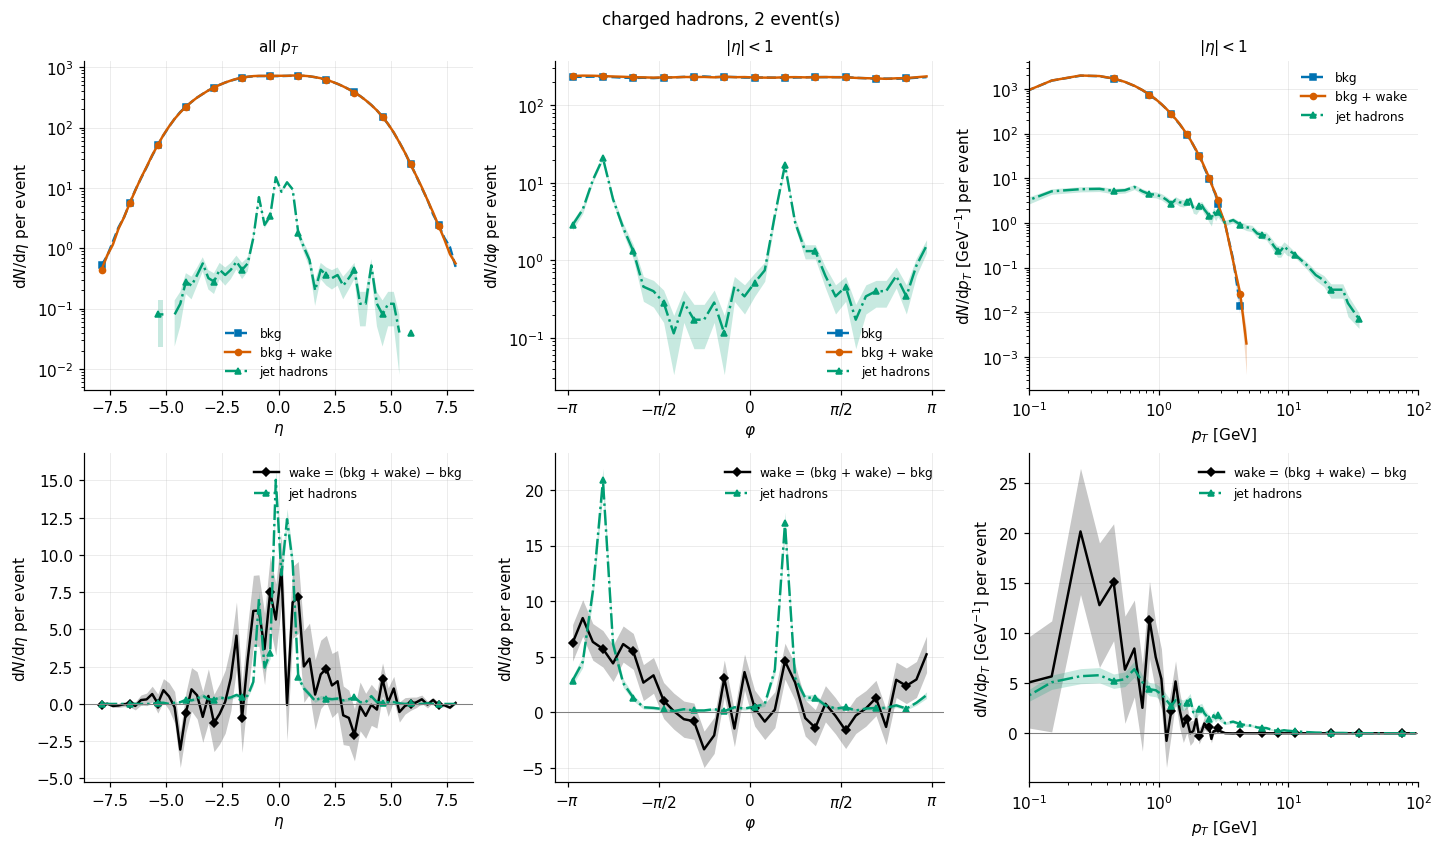

In [5]:
C_PT = {"pt": PT_RANGE}
C_ETA = {"eta": (-ETA_WINDOW, ETA_WINDOW)}
PANELS = [
    ("eta", C_PT,              r"$\eta$",        r"$\mathrm{d}N/\mathrm{d}\eta$"),
    ("phi", {**C_PT, **C_ETA}, r"$\varphi$",     r"$\mathrm{d}N/\mathrm{d}\varphi$"),
    ("pt",  C_ETA,             r"$p_T$ [GeV]",   r"$\mathrm{d}N/\mathrm{d}p_T$ [GeV$^{-1}$]"),
]
PI_TICKS = ([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi], [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])


def lab_figure(hists, top_keys, bottom_keys, title):
    fig, axs = plt.subplots(2, 3, figsize=(13.0, 7.6), constrained_layout=True)
    for j, (axis, cuts, xl, yl) in enumerate(PANELS):
        for row, keys in enumerate((top_keys, bottom_keys)):
            ax = axs[row, j]
            for key in keys:
                draw(ax, *project(hists, key, axis, cuts), key, log=(row == 0))
            if row == 0:
                ax.set_yscale("log")
            else:
                ax.axhline(0, color="0.5", lw=0.7)
            if axis == "pt":
                ax.set_xscale("log")
                ax.set_xlim(0.1, PT_E[-1])
            if axis == "phi":
                ax.set_xticks(*PI_TICKS)
            tidy(ax, xl, yl + " per event", window_text(cuts) if row == 0 else None)
        axs[0, j].legend(fontsize=8)
        axs[1, j].legend(fontsize=8)
    fig.suptitle(title, fontsize=11)
    plt.show()


lab_figure(LAB, ("bulk_bg", "bulk_jet", "jet_frag"), ("wake", "jet_frag"),
           f"{SPECIES} hadrons, {N_EV} event(s)")

### Yields per event

Number and $\sum p_T$ of the selected hadrons in $|\eta| <$ `ETA_WINDOW` (and `PT_RANGE`).
$\sum p_T / N$ shows how much softer the wake's hadrons are than the jet's.

In [6]:
def in_window(ev, info):
    return (ev.species(SPECIES) & (np.abs(ev.eta) < ETA_WINDOW)
            & (ev.pt >= PT_RANGE[0]) & (ev.pt < PT_RANGE[1]))


YIELD = {}
for tag in TAGS:
    scale = np.count_nonzero(N_SAMPLES[tag]) / N_EV
    n = reader.total(tag, mask=in_window, events=EVENTS)
    s = reader.total(tag, mask=in_window, weights="pt", events=EVENTS)
    YIELD[tag] = (n[0] * scale, n[1] * scale, s[0] * scale, s[1] * scale)
j, b = YIELD["bulk_jet"], YIELD["bulk_bg"]
YIELD["wake"] = (j[0] - b[0], np.hypot(j[1], b[1]), j[2] - b[2], np.hypot(j[3], b[3]))

print(f"{SPECIES}, {window_text({**C_ETA, **C_PT}, tex=False)}, per event ({N_EV} event(s)):\n")
print(f"{'':30s} {'N':>18s} {'sum pT [GeV]':>22s}")
for key in ("bulk_bg", "bulk_jet", "wake", "jet_frag"):
    n, dn, s, ds = YIELD[key]
    label = STYLE[key]["label"].replace("$-$", "-")
    print(f"{label:30s} {n:10.1f} +- {dn:5.1f} {s:13.1f} +- {ds:6.1f}   <pT> {s / n:5.2f} GeV")

charged, |eta| < 1, per event (2 event(s)):

                                                N           sum pT [GeV]
bkg                                1438.3 +-   1.2         831.8 +-    0.8   <pT>  0.58 GeV
bkg + wake                         1449.8 +-   1.2         839.5 +-    0.9   <pT>  0.58 GeV
wake = (bkg + wake) - bkg            11.5 +-   1.7           7.8 +-    1.2   <pT>  0.67 GeV
jet hadrons                          15.1 +-   0.4          56.9 +-    2.5   <pT>  3.78 GeV


## 4. Relative to the jet

Each hadron's $\Delta\eta = \eta - \eta_\text{jet}$ and $\Delta\varphi = \varphi - \varphi_\text{jet}$,
measured from the **leading initiator parton** of its event (the highest-$p_T$ parton that starts a
shower, `info.initiators()`). $\Delta\varphi$ runs over
$[-\pi/2, 3\pi/2)$, so the leading jet is at 0 and the recoiling one near $\pi$. Unlike the lab
frame, this keeps the wake's shape when many events are averaged. The $\Delta\varphi$ panel takes
$|\Delta\eta| <$ `ETA_WINDOW`, the $\Delta\eta$ panel the near side $|\Delta\varphi| < \pi/2$.

`hadronize.py` copies each event's initiators into the `bulk_jet` and `jet_frag` files
(`initiators/`). For hadron files made before that, the reader falls back to the pair file
(`<stem>.h5`) next to the particlize file; `hadronize.py <particlize> --add-initiators` adds them
to such files. With neither, this section is skipped.

In [7]:
def leading_initiator(info):
    """(phi, eta) of the event's highest-pT initiator parton."""
    ini = info.initiators()                   # columns shower, pid, pstat, px, py, pz, E, x, y, z, t
    pt = np.hypot(ini[:, 3], ini[:, 4])
    i = int(np.argmax(pt))
    return np.arctan2(ini[i, 4], ini[i, 3]), np.arcsinh(ini[i, 5] / pt[i])


def jet_frame(ev, info):
    phi0, eta0 = leading_initiator(info)
    dphi = np.mod(ev.phi - phi0 + np.pi / 2, 2 * np.pi) - np.pi / 2
    return ev.eta - eta0, dphi, ev.pt


try:
    for e in EVENTS[:3]:
        phi0, eta0 = leading_initiator(reader.event_info(e))
        print(f"event {e}: leading initiator at phi = {phi0:+.2f}, eta = {eta0:+.2f}")
    HAVE_PAIR = True
except FileNotFoundError as exc:
    HAVE_PAIR = False
    print(f"skipping section 4: {exc}")

if HAVE_PAIR:
    AXES_J = ("deta", "dphi", "pt")
    EDGES_J = {"deta": np.linspace(-4.0, 4.0, 33),
               "dphi": np.linspace(-np.pi / 2, 3 * np.pi / 2, 37), "pt": PT_E}
    JET = fill(jet_frame, [EDGES_J[a] for a in AXES_J])

event 0: leading initiator at phi = -2.56, eta = +0.44
event 1: leading initiator at phi = +0.53, eta = +0.34
  bulk_jet      4594.1 hadrons per event inside the bins   (1.5 s)
  bulk_bg       4576.9 hadrons per event inside the bins   (1.5 s)
  jet_frag        17.8 hadrons per event inside the bins   (0.0 s)


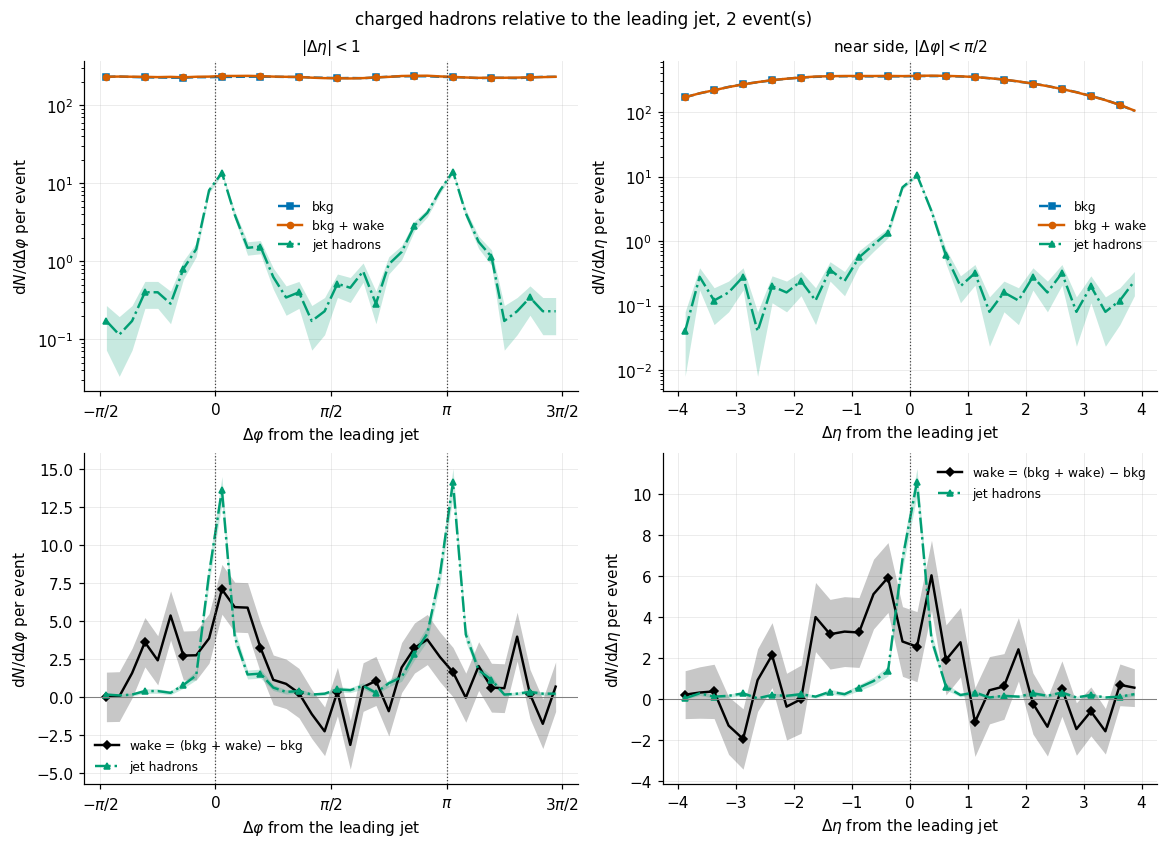

In [8]:
if HAVE_PAIR:
    C_DETA = {"deta": (-ETA_WINDOW, ETA_WINDOW)}
    C_NEAR = {"dphi": (-np.pi / 2, np.pi / 2)}
    PANELS_J = [
        ("dphi", {**C_PT, **C_DETA}, r"$\Delta\varphi$ from the leading jet",
         r"$\mathrm{d}N/\mathrm{d}\Delta\varphi$", rf"$|\Delta\eta|<{ETA_WINDOW:g}$"),
        ("deta", {**C_PT, **C_NEAR}, r"$\Delta\eta$ from the leading jet",
         r"$\mathrm{d}N/\mathrm{d}\Delta\eta$", r"near side, $|\Delta\varphi|<\pi/2$"),
    ]
    fig, axs = plt.subplots(2, 2, figsize=(10.5, 7.6), constrained_layout=True)
    for j, (axis, cuts, xl, yl, title) in enumerate(PANELS_J):
        for row, keys in enumerate((("bulk_bg", "bulk_jet", "jet_frag"), ("wake", "jet_frag"))):
            ax = axs[row, j]
            for key in keys:
                draw(ax, *project(JET, key, axis, cuts, AXES_J, EDGES_J), key, log=(row == 0))
            if row == 0:
                ax.set_yscale("log")
            else:
                ax.axhline(0, color="0.5", lw=0.7)
            if axis == "dphi":
                ax.set_xticks([-np.pi / 2, 0, np.pi / 2, np.pi, 3 * np.pi / 2],
                              [r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$"])
                ax.axvline(np.pi, color="0.25", lw=0.8, ls=":")
            ax.axvline(0, color="0.25", lw=0.8, ls=":")
            tidy(ax, xl, yl + " per event", title if row == 0 else None)
            ax.legend(fontsize=8)
    fig.suptitle(f"{SPECIES} hadrons relative to the leading jet, {N_EV} event(s)", fontsize=11)
    plt.show()

## Next steps

- **Reconstructed jets.** "Jet" here means the fragmentation hadrons. Anti-$k_T$ jets on
  bkg + wake + jet hadrons, with background subtraction against bkg, need `fastjet`, which none of
  the local envs have yet (`pip install fastjet`).
- **Event-to-event errors.** With many events, bootstrap over events instead of the sampling
  errors shown here.
- **More observables.** Change `SPECIES` for identified hadrons. Jet-shape and $\Delta R$ profiles
  come from `jet_frame` with $\Delta R = \sqrt{\Delta\eta^2 + \Delta\varphi^2}$ as the value.